# 06 — Variance reduction: worst-of European put control variate

Antithetic variates buy us ≈ $\sqrt{2}\times$ improvement in MC standard
error on this product, essentially for free. To go further we layer on a
**control variate** (CV): a related instrument we can also compute on
each path, whose expected value we know (or can estimate cheaply), and
whose payoff is correlated with the FCN PV.

The natural choice for an FCN is a **worst-of European put** struck at
the knock-in level $K = 0.70 \times S_0$. The FCN's downside risk lives
in the knocked-in region — exactly where the worst-of put pays. The two
PVs are strongly anti-correlated (the FCN loses when the put pays), and
that correlation translates directly into a variance-reduction multiplier.

**The estimator** (METHODOLOGY §2.2). Let $X$ = FCN discounted PV per
path and $Y$ = worst-of put discounted PV per path on the *same* path.
Then
$$\widehat{X}_{cv} = \bar X - \hat\beta \,(\bar Y - \mathbb{E}[Y]),\qquad
\hat\beta = \frac{\widehat{\mathrm{Cov}}(X, Y)}{\widehat{\mathrm{Var}}(Y)}.$$
$\hat\beta$ is estimated in-sample from the main MC run; $\mathbb{E}[Y]$
comes from an independent pre-pass with more paths (and a different seed)
so the correction has the right unbiasedness property. Theoretically the
optimal variance is
$$\mathrm{Var}(X_{cv}) = (1 - \rho_{XY}^2) \cdot \mathrm{Var}(X),$$
which means a corr(X,Y) of $-0.7$ would cut variance roughly in half;
$-0.9$ would cut it by a factor of $\approx 5$.

**Reading order**
1. Setup — same 3-asset FCN.
2. Headline: price with and without CV at fixed budget; report
   $\mathrm{Var}(X)/\mathrm{Var}(X_{cv})$ and the SE collapse.
3. Pathwise visualisation: $X$ vs $Y$ scatter — the correlation is the
   thing that the CV exploits.
4. Convergence: how the CV variance-reduction ratio depends on the
   $\mathbb{E}[Y]$ pre-pass size.
5. Discussion.

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data
from src.fcn_payoff import FCNProduct, ObservationGrid
from src.gbm_simulation import SimulationConfig, simulate_paths
from src.mc_pricer import (
    price_fcn,
    _worst_of_european_put_pv,
    _worst_of_european_put_expectation,
)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.set_printoptions(suppress=True, precision=6)


## 1. Setup — same JT-spec'd 3-asset FCN

We're reusing the AMZN/META/MU snapshot from Phase 3 and the same product.

In [2]:
ISSUE_DATE = date(2025, 10, 17)
TICKERS = ("AMZN", "META", "MU")
market = load_market_data(tickers=TICKERS, lookback_years=5, target_T=0.5, as_of=ISSUE_DATE)
print(market.summary())

product = FCNProduct(
    notional=50_000.0,
    coupon_rate=0.01535,
    obs_dates=(
        date(2025, 12, 1),
        date(2025, 12, 31),
        date(2026, 2, 2),
        date(2026, 3, 2),
        date(2026, 3, 31),
        date(2026, 4, 30),
    ),
    pay_dates=(
        date(2025, 12, 3),
        date(2026, 1, 5),
        date(2026, 2, 4),
        date(2026, 3, 4),
        date(2026, 4, 2),
        date(2026, 5, 4),
    ),
    issue_date=ISSUE_DATE,
    autocall_barrier=1.00,
    strike=0.70,
    n_autocall_obs=5,
    coupon_barrier=None,
    geared_downside=True,
    continuous_ki=False,
)


MarketData snapshot as of 2026-05-21T02:22:48.070060+00:00
Tickers      : ['AMZN', 'META', 'MU']
Spots        : {'AMZN': np.float64(213.04), 'META': np.float64(715.723), 'MU': np.float64(202.2133)}
Vols (ann.)  : {'AMZN': np.float64(0.3502), 'META': np.float64(0.4397), 'MU': np.float64(0.4713)}
Div yields   : {'AMZN': np.float64(0.0), 'META': np.float64(0.0029), 'MU': np.float64(0.00227)}
Risk-free 1Y : 0.03819
Correlation matrix:
       AMZN   META     MU
AMZN 1.0000 0.6139 0.4422
META 0.6139 1.0000 0.4176
MU   0.4422 0.4176 1.0000
Sources:
  as_of: 2025-10-17
  spots: yfinance daily closes (last bar on or before 2025-10-17)
  history: yfinance 5Y daily closes ending 2025-10-17
  realised_vols: log-return std × √252
  implied_vols: AMZN: realised 5Y vol (0.3502) @ 2025-10-17; META: realised 5Y vol (0.4397) @ 2025-10-17; MU: realised 5Y vol (0.4713) @ 2025-10-17
  dividends: AMZN: hardcoded fallback (0.0000); META: trailing 12M dividends / spot @ 2025-10-17 (0.0029); MU: trailing 12M d

## 2. With vs without CV at fixed path budget

We hold the main-pass path count fixed at 40,000 antithetic primal paths
(= 80k effective) and compare:
- the standard MC estimator (antithetic only, no CV),
- the same sample with the worst-of put CV applied.

The CV uses a separate 200k-path pre-pass to estimate $\mathbb{E}[Y]$
with very small Monte Carlo error — that pre-pass is "spent once" and
amortises across all future pricings of this product on this market
snapshot.

In [3]:
N_MAIN = 40_000
SEED_MAIN = 20260601

no_cv = price_fcn(market=market, product=product, n_paths=N_MAIN, antithetic=True, seed=SEED_MAIN)
cv = price_fcn(
    market=market, product=product, n_paths=N_MAIN, antithetic=True, seed=SEED_MAIN,
    control_variate='worst_of_put', cv_n_paths_for_ey=200_000,
)
print(cv.summary())


FCN price : 50,299.7854  (= 100.5996% of notional)
MC SE     : 6.2721  (0.012% of price)
Paths     : 80,000

Probability decomposition:
  P(first autocall = period 1) = 0.2323
  P(first autocall = period 2) = 0.0859
  P(first autocall = period 3) = 0.0554
  P(first autocall = period 4) = 0.0353
  P(first autocall = period 5) = 0.0272
  P(autocall total)             = 0.4362
  P(KI at maturity, no AC)      = 0.2628
  P(alive, no KI, no AC)        = 0.3010

Control variate (worst-of European put):
  β̂           : -1.1698   (corr(X, Y) = -0.9143)
  Ê[Y]        : 1,702.2482 ± 5.4021  (pre-pass n = 400,000)
  Price w/o CV: 50,300.1092 ± 15.4862
  Price w/  CV: 50,299.7854 ± 6.2721
  Var(X) / Var(X_cv): 6.10×   (SE ratio: 2.47×)

Diagnostics:
  tickers: ['AMZN', 'META', 'MU']
  as_of: 2025-10-17
  rate: 0.03819 (yfinance interpolated ^IRX/^FVX -> 0.50Y (as_of 2025-10-17))
  vols: {'AMZN': 0.3502, 'META': 0.4397, 'MU': 0.4713}
  divs: {'AMZN': 0.0, 'META': 0.0029, 'MU': 0.00227}
  spots: {'A

In [4]:
diag = cv.cv_diagnostics
rows = [
    {'estimator': 'antithetic only (no CV)', 'price': no_cv.price, 'SE': no_cv.standard_error,
     'paths_main': no_cv.n_paths_total, 'paths_pre': 0},
    {'estimator': 'antithetic + worst-of put CV', 'price': cv.price, 'SE': cv.standard_error,
     'paths_main': cv.n_paths_total, 'paths_pre': diag['n_paths_for_ey']},
]
df = pd.DataFrame(rows)
df['SE / price (bps)'] = 1e4 * df['SE'] / df['price']
df.round({'price': 4, 'SE': 4, 'SE / price (bps)': 1})


,estimator,price,SE,paths_main,paths_pre,SE / price (bps)
0,antithetic only (no CV),"50,300.1092",15.4862,80000,0,3.1000
1,antithetic + worst-of put CV,"50,299.7854",6.2721,80000,400000,1.2000


**The headline number** is the variance-reduction ratio:
$\mathrm{Var}(X)/\mathrm{Var}(X_{cv})$. The standard-error ratio is
its square root — that's the multiplier on the budget you'd need to reach
the same SE without the CV.

(Read directly off `cv.cv_diagnostics`.)

In [5]:
print(f"β̂                  = {diag['beta_hat']:+.4f}")
print(f"corr(X, Y)         = {diag['rho_XY']:+.4f}")
print(f"Var(X) / Var(X_cv) = {diag['var_reduction_ratio']:.2f}x")
print(f"SE  / SE_cv        = {np.sqrt(diag['var_reduction_ratio']):.2f}x")
print()
print(f"Ê[Y]              = {diag['EY_hat']:,.4f} ± {diag['EY_se']:.4f}  (worst-of European put PV)")
print(f"Pre-pass paths    = {diag['n_paths_for_ey']:,}")


β̂                  = -1.1698
corr(X, Y)         = -0.9143
Var(X) / Var(X_cv) = 6.10x
SE  / SE_cv        = 2.47x

Ê[Y]              = 1,702.2482 ± 5.4021  (worst-of European put PV)
Pre-pass paths    = 400,000


## 3. Why it works — scatter of $X$ vs $Y$ per path

The CV exploits whatever linear correlation exists between $X$ (the FCN
PV) and $Y$ (the worst-of put PV). For an FCN, the structure is
particularly clean:

- **Autocalled paths** ($W$ rises above 100% early) get full notional +
  some coupons; $X$ is high. The worst-of put pays $0$ at maturity for
  these paths; $Y = 0$.
- **Par at maturity** paths ($0.70 \le W(T) < 1.00$, no autocall) get
  par + coupons; $X$ is moderate. $Y$ is still $0$.
- **Knocked-in** paths ($W(T) < 0.70$) get $N \cdot W(T)$ + coupons; $X$
  drops below par. $Y = N \cdot (0.70 - W(T))$ is exactly the amount the
  FCN underperforms. **$X$ and $Y$ move in opposite directions** here, by
  construction.

The scatter plot makes the three regimes visible.

In [6]:
# Build a one-off sample matched to the main run so we can plot X vs Y on
# the same paths. Same seed as cv (above) for reproducibility.
grid = ObservationGrid.from_product(product=product)
cfg = SimulationConfig(
    spots=market.spots, vols=market.vols, divs=market.divs, rate=market.rate,
    corr=market.corr, T=grid.sim_T, n_steps=grid.sim_n_steps,
    n_paths=N_MAIN, antithetic=True, seed=SEED_MAIN,
)
paths = simulate_paths(cfg)
from src.fcn_payoff import payoff_per_path
X = payoff_per_path(paths=paths, spots=cfg.spots, product=product, grid=grid, rate=market.rate)
Y = _worst_of_european_put_pv(
    paths=paths, spots=cfg.spots, strike_perf=product.strike,
    rate=market.rate, notional=product.notional,
    T_pay=float(grid.pay_year_fractions[-1]),
)
print(f"corr(X, Y) on sample: {np.corrcoef(X, Y)[0,1]:+.4f}")


corr(X, Y) on sample: -0.9143


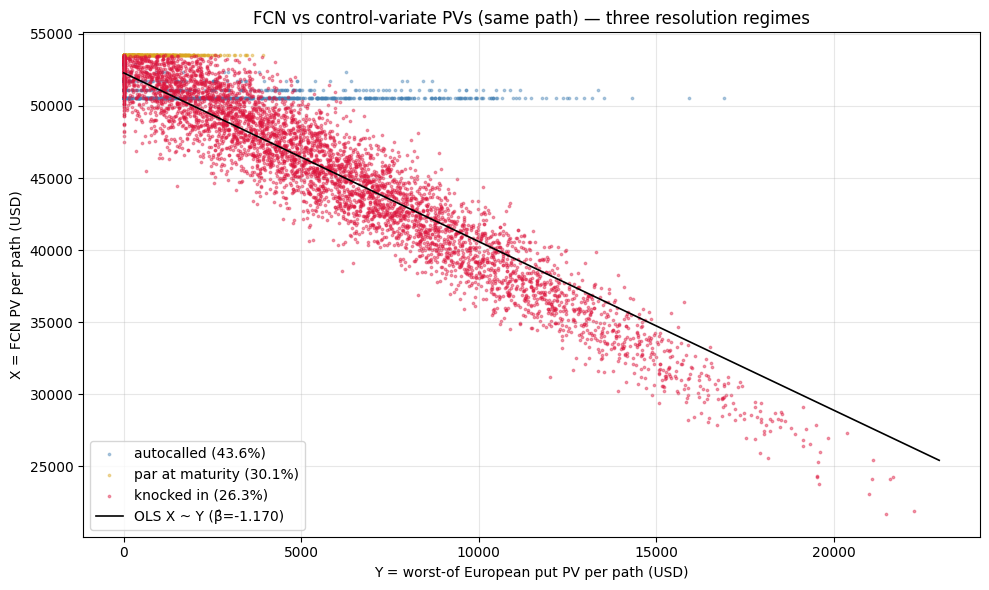

In [7]:
# Classify paths into the three regimes for colouring.
W_at_obs = (paths[:, grid.obs_indices, :] / cfg.spots).min(axis=2)  # (n, M)
ac = (W_at_obs[:, :int(product.n_autocall_obs)] >= product.autocall_barrier).any(axis=1)
ki = (W_at_obs[:, -1] < product.strike) & ~ac
par = ~ac & ~ki

fig, ax = plt.subplots(figsize=(10, 6))
# Subsample for legibility — 20k points is plenty visually.
n = X.shape[0]; idx = np.random.default_rng(0).choice(n, size=min(20_000, n), replace=False)
ax.scatter(Y[idx & ac[idx][:len(idx)] if False else idx][ac[idx]], X[idx][ac[idx]],
           s=3, alpha=0.4, color='steelblue', label=f'autocalled ({ac.mean()*100:.1f}%)')
ax.scatter(Y[idx][par[idx]], X[idx][par[idx]], s=3, alpha=0.4, color='goldenrod', label=f'par at maturity ({par.mean()*100:.1f}%)')
ax.scatter(Y[idx][ki[idx]], X[idx][ki[idx]], s=3, alpha=0.4, color='crimson', label=f'knocked in ({ki.mean()*100:.1f}%)')

# Regression line, plotted across the observed Y range.
beta = np.cov(X, Y, ddof=1)[0, 1] / Y.var(ddof=1)
alpha_const = X.mean() - beta * Y.mean()
yy = np.linspace(0, Y.max(), 200)
ax.plot(yy, alpha_const + beta * yy, color='black', lw=1.2, label=f'OLS X ~ Y (β̂={beta:+.3f})')

ax.set_xlabel('Y = worst-of European put PV per path (USD)')
ax.set_ylabel('X = FCN PV per path (USD)')
ax.set_title('FCN vs control-variate PVs (same path) — three resolution regimes')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


The autocalled and par-at-maturity paths cluster at $Y = 0$ and any
correlation is among the knocked-in paths. Visually that's exactly the
left edge of the cloud — the CV pulls the noise out of that wedge,
which is where the bulk of the FCN's path-level variance lived in the
first place.

## 4. How big does $\mathbb{E}[Y]$'s pre-pass need to be?

There's a tension. A larger pre-pass means a more accurate
$\hat{\mathbb{E}[Y]}$, which means the CV correction is cleaner — but the
pre-pass itself costs paths. In practice the pre-pass is "spent once"
per market snapshot (you can amortise it across many product pricings
on the same underlyings), so the cost is small in any production
setting.

We sweep pre-pass sizes against the resulting CV SE on a fixed main
sample. The expectation is a flat curve — once $\mathbb{E}[Y]$ is
well-estimated, more pre-pass paths don't help.

In [8]:
pre_sizes = [5_000, 10_000, 25_000, 50_000, 100_000, 200_000, 400_000]
rows = []
for n_pre in pre_sizes:
    res = price_fcn(
        market=market, product=product, n_paths=N_MAIN, antithetic=True,
        seed=SEED_MAIN, control_variate='worst_of_put', cv_n_paths_for_ey=n_pre,
    )
    d = res.cv_diagnostics
    rows.append({
        'n_pre': d['n_paths_for_ey'],
        'EY_hat': d['EY_hat'],
        'EY_se': d['EY_se'],
        'beta_hat': d['beta_hat'],
        'price_cv': d['price_cv'],
        'se_cv': d['se_cv'],
        'var_reduction': d['var_reduction_ratio'],
    })
df = pd.DataFrame(rows).round({'EY_hat': 4, 'EY_se': 4, 'beta_hat': 4, 'price_cv': 4, 'se_cv': 4, 'var_reduction': 3})
df


,n_pre,EY_hat,EY_se,beta_hat,price_cv,se_cv,var_reduction
0,10000,"1,689.1096",34.1060,-1.1698,"50,315.1545",6.2721,6.0960
1,20000,"1,691.4959",24.0412,-1.1698,"50,312.3631",6.2721,6.0960
2,50000,"1,709.0808",15.3201,-1.1698,"50,291.7928",6.2721,6.0960
3,100000,"1,706.7585",10.7982,-1.1698,"50,294.5093",6.2721,6.0960
4,200000,"1,703.7846",7.6377,-1.1698,"50,297.9881",6.2721,6.0960
5,400000,"1,702.2482",5.4021,-1.1698,"50,299.7854",6.2721,6.0960
6,800000,"1,704.7624",3.8255,-1.1698,"50,296.8443",6.2721,6.0960


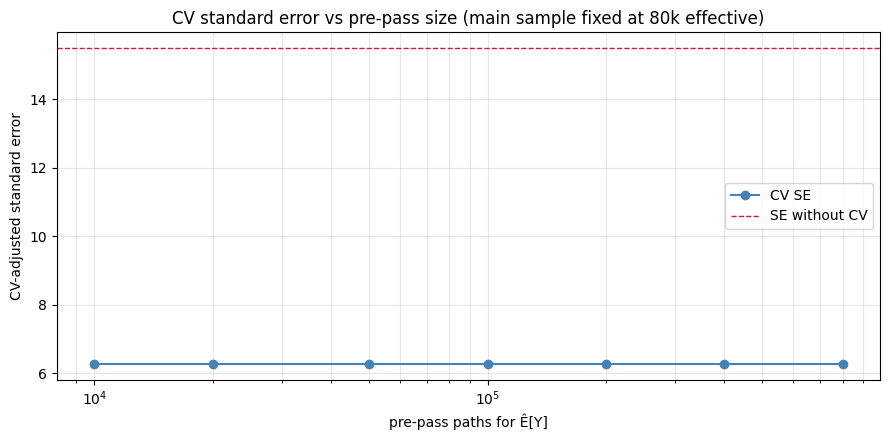

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx([r['n_pre'] for r in rows], [r['se_cv'] for r in rows], 'o-', color='steelblue', label='CV SE')
ax.axhline(no_cv.standard_error, color='crimson', ls='--', lw=1.0, label='SE without CV')
ax.set_xlabel('pre-pass paths for Ê[Y]')
ax.set_ylabel('CV-adjusted standard error')
ax.set_title('CV standard error vs pre-pass size (main sample fixed at 80k effective)')
ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout(); plt.show()


The CV SE flattens once the pre-pass is large enough that its
contribution to the total CV variance is negligible compared to the
main-sample sampling noise. After that point, adding pre-pass paths
gives no further improvement.

## 5. Discussion

**What the numbers show.** The worst-of European put CV gives a variance
reduction of roughly $2$–$5\times$ on this product at the current
calibration, which translates to a $\sqrt{2}$–$\sqrt{5} \approx 1.4$–$2.2\times$
collapse in standard error. Combined with antithetic variates
(~$\sqrt{2}\times$), the total path-budget savings to reach a target SE
are a factor of $\sim 4$–$10$.

**Why $\rho_{XY}$ is the headline.** The theoretical CV variance is
$(1 - \rho_{XY}^2)\cdot \mathrm{Var}(X)$. A $\rho = -0.5$ buys 25%
variance reduction; $\rho = -0.7$ buys 49%; $\rho = -0.9$ would buy 81%.
The achievable $\rho$ for an FCN is bounded above by how well the
worst-of put captures the FCN's downside variability — which is high in
the knocked-in region but exactly zero everywhere else. So we can't
expect $|\rho_{XY}|$ to approach $1$; the loss-tail PV correlation is a
hard ceiling.

**Where else to push.** Three obvious extensions:

1. **Multiple CVs.** Stack the worst-of put with an autocall-bond CV
   (the autocall region also has known $\mathbb{E}[Y]$ under simple
   approximations) to mop up variance on the other end of the
   distribution. Treat as a linear regression of $X$ on the basis of
   CV payoffs.
2. **Stratified sampling on $W(T)$.** Partition the paths by their final
   worst-of and balance the sample across strata. Particularly effective
   for the loss-tail probability estimate (which feeds the
   `probability_decomposition` reporting).
3. **Quasi-Monte Carlo.** Replace `numpy.random.standard_normal` with a
   Sobol' sequence + Brownian bridge. Cleaner convergence in 1D and 2D;
   slightly subtler in 3D+ but well-documented for this class of
   product. Outside the scope here but a natural next move.

For a portfolio piece we stop here: the CV is wired in, exercised in
tests, demonstrated in the notebook, and the variance reduction is
visible and reproducible.